/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

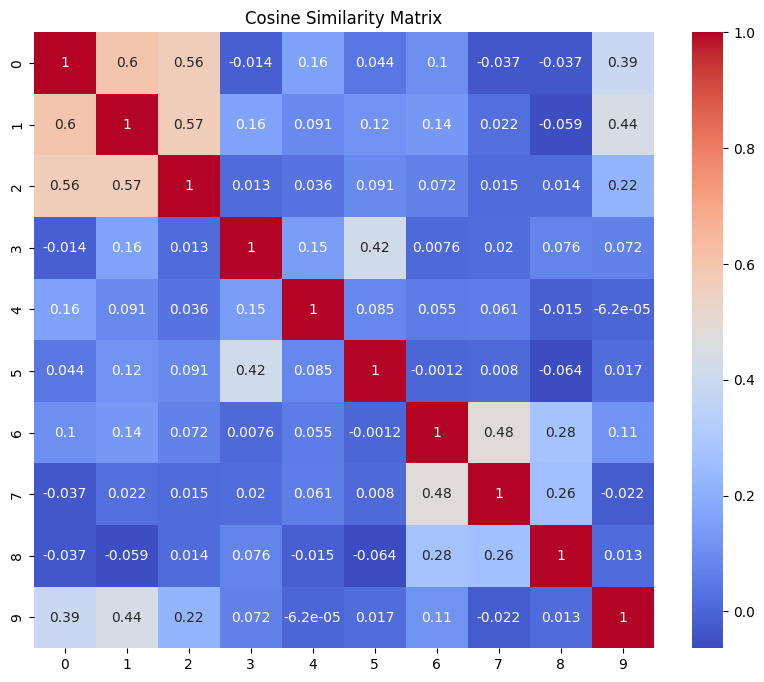


Query: The bowler took three wickets in one over

Top 2 similar sentences:
The bowler took five wickets in the game (Score: 0.8470)
The batsman scored a century in the match (Score: 0.5682)


In [1]:
# Install required libraries
!pip install sentence-transformers seaborn matplotlib

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Create sentences (3 topics)
sentences = [
    # Cricket
    "The batsman scored a century in the match",
    "The bowler took five wickets in the game",
    "The team won the cricket tournament",

    # Cooking
    "The chef prepared a delicious pasta",
    "Baking a cake requires precise measurements",
    "The recipe includes fresh vegetables and spices",

    # Cybersecurity
    "Cyber attacks can compromise sensitive data",
    "Encryption helps protect information online",
    "Firewalls prevent unauthorized access",

    # Extra (mixed)
    "The player hit a six in the last over"
]

# Step 2: Load model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Step 3: Generate embeddings
embeddings = model.encode(sentences)

# Step 4: Cosine similarity matrix
similarity_matrix = cosine_similarity(embeddings)

# Step 5: Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(similarity_matrix, annot=True, cmap="coolwarm")
plt.title("Cosine Similarity Matrix")
plt.show()

# Step 6: Query similarity
query = "The bowler took three wickets in one over"
query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

# Get top 2 similar sentences
top_indices = similarities.argsort()[-2:][::-1]

print("\nQuery:", query)
print("\nTop 2 similar sentences:")
for idx in top_indices:
    print(f"{sentences[idx]} (Score: {similarities[idx]:.4f})")